In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, get_color, get_color_and_match, get_msmhmr

from multicam.multicam import MultiCamSampling, MultiCAM

from multicam_tng.utils import TNG_H

In [2]:
# stellar mass of 100 particles (should be the lowest mass we consider)
np.log10(1.4e6 * 100 * TNG_H)

np.float64(7.97697322798685)

In [3]:
# read tree data 
hydro_data = {} 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    out = np.load(fp)
    for k in out: 
        hydro_data[k] = out[k]


In [4]:
# how complete? 
# compute number of galaxies in stellar bin that are not in mpeak bin
cond1 = (hydro_data['stellar_mass'] > 10**9.5 ) & (hydro_data['stellar_mass'] < 10**10.2 )
cond2 = (hydro_data['mpeak'] < 10**11 ) | (hydro_data['mpeak'] > 10**12 )
sum(cond1 & cond2) / sum(cond1) # ~ 1% is OK

np.float64(0.013070283600493218)

In [5]:
hydro_data.keys()

dict_keys(['subfind_id', 'vpeak', 'mpeak_mah', 'is_sub', 'a12', 'mpeak_pre', 'mpeak', 'stellar_mass'])

In [6]:
# sort array by subfind ids to match with color data
_sort_mask = np.argsort(hydro_data['subfind_id'])
for k in hydro_data:
    hydro_data[k] = hydro_data[k][_sort_mask]

In [7]:
hydro_data['subfind_id'], hydro_data['stellar_mass'], hydro_data['mpeak']

(array([      0,       1,       2, ..., 3577883, 3741554, 4263941],
       shape=(101431,)),
 array([1.6383422e+12, 2.5731015e+11, 2.8852679e+11, ..., 1.9287528e+06,
        0.0000000e+00, 0.0000000e+00], shape=(101431,), dtype=float32),
 array([2.7477936e+14, 3.7301757e+13, 4.1831337e+13, ..., 1.8157779e+10,
        1.0704213e+10, 1.3181168e+10], shape=(101431,), dtype=float32))

In [8]:
# define stellar mass bin to be used throughout

stellar_mass_bin = (9.5, 10.2 ) # log10 Msun / h units 
cond1 = hydro_data['stellar_mass'] > 10**stellar_mass_bin[0]
cond2 = hydro_data['stellar_mass'] < 10**stellar_mass_bin[1]
stellar_mask = cond1 & cond2
sum(stellar_mask)

np.int64(4055)

In [9]:
# see notebook "2025-11-10 Mass bin MultiCAM Trying Mpeak"
mpeak_mass_bin = (11, 12) # log10 Msun / h units 

mpeak = np.log10(hydro_data['mpeak']) # min = 1e10
left_cond = mpeak > mpeak_mass_bin[0]
right_cond = mpeak < mpeak_mass_bin[1]
# star_cond =hydro_data['stellar_mass'] > 0
star_cond = hydro_data['stellar_mass'] > np.log10(1.4e6 * 100 * TNG_H)
mpeak_mask = left_cond & right_cond & star_cond
sum(mpeak_mask)

np.int64(11316)

In [10]:
# get colors
color_file = "../../data/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"
colors = get_color_and_match(color_file, hydro_data['subfind_id'])
gi_color = colors['sdss_g'].values - colors['sdss_i'].values
gi_color.shape

(101431,)

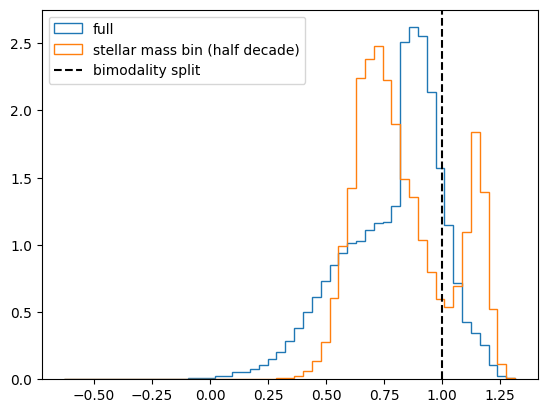

In [11]:
_, bins, _ = plt.hist(gi_color, bins=51, density=True, histtype='step', label='full');

# just as an example to see bimodality
plt.hist(gi_color[stellar_mask], bins=bins, density=True, 
         histtype='step', label='stellar mass bin (half decade)');

plt.axvline(1.0, c='k', ls='--', label='bimodality split')
plt.legend()


Text(0, 0.5, 'log10 Stellar Mass')

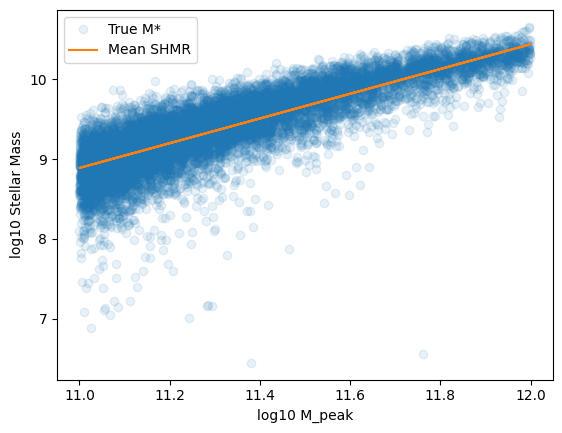

In [12]:
# get deviation from mean SHMR and check that it looks correct
_smass = np.log10(hydro_data['stellar_mass'][mpeak_mask])
_mpeak =  mpeak[mpeak_mask] # already log10

mstar_dev, (m, b) = get_msmhmr(_smass,_mpeak, n_bins=11, mass_bin=mpeak_mass_bin)

_y_pred = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak)
plt.plot(_mpeak, _smass, 'o', alpha=0.1, label='True M*')
plt.plot(_mpeak, _y_pred, '-', label="Mean SHMR")
plt.legend()

plt.xlabel("log10 M_peak")
plt.ylabel("log10 Stellar Mass") 



In [13]:
# get snapshot redshifts and scales
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
redshift =metadata['Redshift'].values
scales = 1 / (1 + redshift)

# Preliminary Look at Correlations

In [14]:
# correlation deviation and a12 
from scipy.stats import spearmanr
spearmanr(mstar_dev, hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6496573288768798), pvalue=np.float64(0.0))

In [15]:
spearmanr(gi_color[mpeak_mask], hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6239754787528624), pvalue=np.float64(0.0))

In [16]:
# correlation across MAH (deviation and color)
mah = hydro_data['mpeak_mah'][mpeak_mask]
color = gi_color[mpeak_mask]
n_snaps = mah.shape[1]

corrs_mstar_dev = [] 
corrs_color = [] 
for ii in range(n_snaps):
    corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
    corrs_color.append(spearmanr(color, mah[:, ii]).statistic)

corrs_mstar_dev = np.array(corrs_mstar_dev)
corrs_color = np.array(corrs_color)
    

/tmp/ipykernel_21345/1328140465.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
/tmp/ipykernel_21345/1328140465.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_color.append(spearmanr(color, mah[:, ii]).statistic)


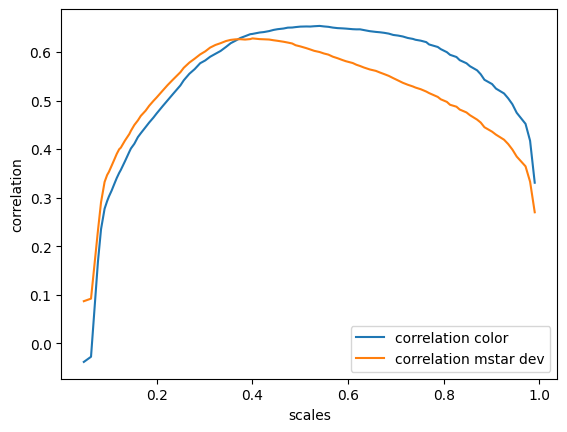

In [17]:
plt.plot(scales, corrs_color, label='correlation color')
plt.plot(scales, corrs_mstar_dev, label='correlation mstar dev')
plt.xlabel('scales')
plt.ylabel('correlation')
plt.legend()

# Train and Apply MultiCAM (Linear, $a_{1/2}$)

In [19]:
# x = mah
x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 1), (11316, 2))

In [20]:
model = MultiCAM(x.shape[1], 2)
model.fit(x,y)

In [21]:
y_pred = model.predict(x)
y_pred.shape

(11316, 2)

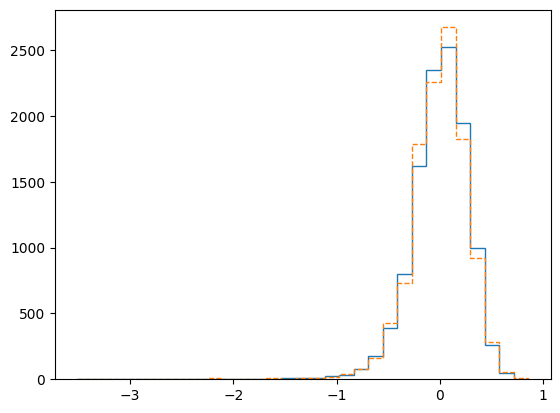

In [22]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');


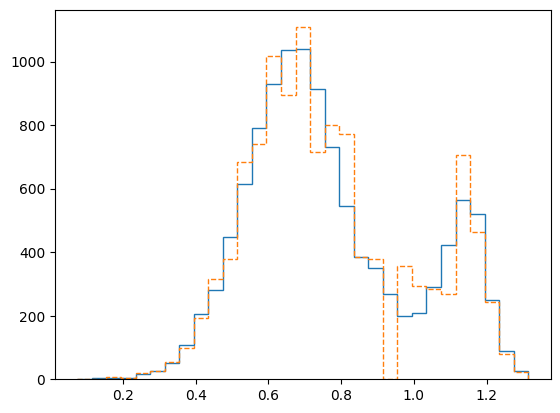

In [23]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--');

## CAM direct comparison

SignificanceResult(statistic=np.float64(-0.6319217396564742), pvalue=np.float64(0.0))


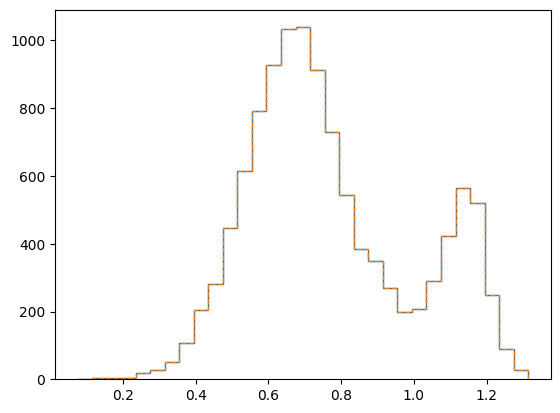

In [24]:
# cam is perfect so why not multicam vanilla
from multicam.qt import qt
cam_color_pred = qt(hydro_data['a12'][mpeak_mask], y[:, 1])
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step')
plt.hist(cam_color_pred, bins=bins, histtype='step', ls='--');
print(spearmanr(cam_color_pred, y[:, 1])) # and achives the same spearman correlation as multicam with just a1/2, close enough

In [25]:
# prediction spearmanr (these are what we expect I think)
# higher than a_1/2 but color distribution is wonky...
spearmanr(y_pred[:, 0], y[:, 0]), spearmanr(y_pred[:, 1], y[:, 1])

(SignificanceResult(statistic=np.float64(0.6496573288768799), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.6239754787528624), pvalue=np.float64(0.0)))

In [26]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(3657)

In [27]:
# actual number of stars in bin
smass_true = np.log10(hydro_data['stellar_mass'][mpeak_mask])
sum((smass_true > 9.5) & (smass_true < 10.2))

np.int64(4002)

(array([299., 267., 258., 228., 246., 218., 185., 207., 177., 197., 164.,
        155., 153., 144., 142., 133.,  93., 109.,  95.,  95.,  90.]),
 array([ 9.50012016,  9.53342056,  9.56672001,  9.60002041,  9.63332081,
         9.66662025,  9.69992065,  9.73322105,  9.7665205 ,  9.7998209 ,
         9.8331213 ,  9.86642075,  9.89972115,  9.93302155,  9.96632099,
         9.99962139, 10.03292179, 10.06622124, 10.09952164, 10.13282204,
        10.16612148, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x7080a3bbf750>])

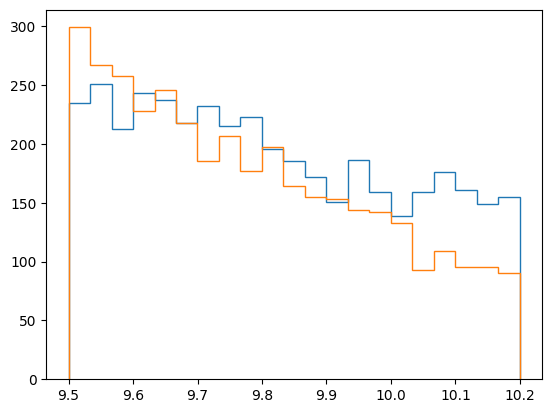

In [28]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step')
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step')

In [ ]:
# split in red and blue
smass = np.log10(hydro_data['stellar_mass'][stellar_mask])
mask_red = gi_color[stellar_mask] > 1.0
mask_blue = gi_color[stellar_mask] < 1.0 
smass_red = smass[mask_red]
smass_blue = smass[mask_blue]

pred_color = y_pred[:, 1][pred_stellar_mask]
pred_red_mask = pred_color > 1.0
pred_blue_mask = pred_color < 1.0 


smass_pred_red = pred_mstar[pred_stellar_mask][pred_red_mask]
smass_pred_blue = pred_mstar[pred_stellar_mask][pred_blue_mask]

In [30]:
smass_blue.shape, smass_red.shape, smass_pred_blue.shape, smass_pred_red.shape

((3072,), (983,), (2544,), (1113,))

(array([2.28245277, 2.15230311, 2.04592917, 1.79757939, 1.92766737,
        1.77387619, 1.45462016, 1.72662231, 1.60831441, 1.59653432,
        1.4309678 , 1.312706  , 1.34814591, 1.15896566, 1.1944442 ,
        1.09980324, 0.82783261, 0.82783261, 0.91061587, 0.79233137,
        0.78052789]),
 array([ 9.50012016,  9.53339767,  9.56667614,  9.59995365,  9.63323116,
         9.66650867,  9.69978714,  9.73306465,  9.76634216,  9.79962063,
         9.83289814,  9.86617565,  9.89945316,  9.93273163,  9.96600914,
         9.99928665, 10.03256512, 10.06584263, 10.09912014, 10.13239765,
        10.16567612, 10.19895363]),
 [<matplotlib.patches.Polygon at 0x7080a3a565d0>])

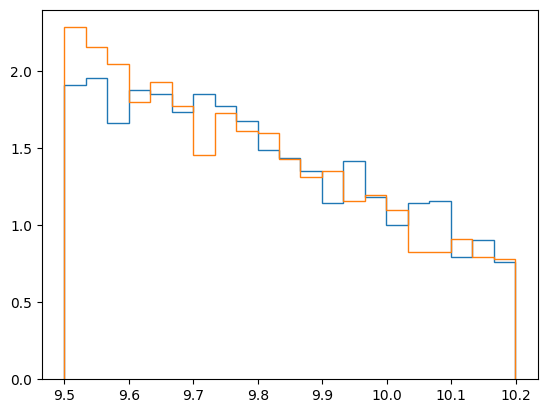

In [31]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( smass_blue, bins=21, histtype='step', density=True)
plt.hist(smass_pred_blue, bins=bins, histtype='step', density=True)

(array([2.88943183, 2.29534304, 2.29534304, 2.05236555, 2.26833901,
        1.78226636, 1.67425022, 1.62024215, 1.1341695 , 1.64724618,
        1.13420201, 1.21518161, 1.0531574 , 1.24218565, 1.1341695 ,
        1.02615336, 0.6751009 , 1.02618277, 0.48607264, 0.756113  ,
        0.64809686]),
 array([ 9.50071716,  9.53398895,  9.56726074,  9.60053253,  9.63380337,
         9.66707516,  9.70034695,  9.73361874,  9.76689053,  9.80016232,
         9.8334341 ,  9.86670494,  9.89997673,  9.93324852,  9.96652031,
         9.9997921 , 10.03306389, 10.06633568, 10.09960651, 10.1328783 ,
        10.16615009, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x7080a3adc7d0>])

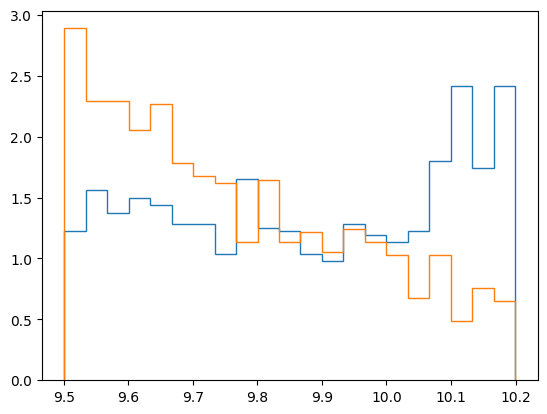

In [32]:
_, bins, _ = plt.hist( smass_red, bins=21, histtype='step', density=True)
plt.hist(smass_pred_red, bins=bins, histtype='step', density=True)

# Sampling ($a_{1/2}$)

In [35]:
x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 1), (11316, 2))

In [36]:
model = MultiCamSampling(x.shape[1], 2)
model.fit(x,y)

In [37]:
y_pred = model.sample(x)
y_pred.shape

(11316, 2)

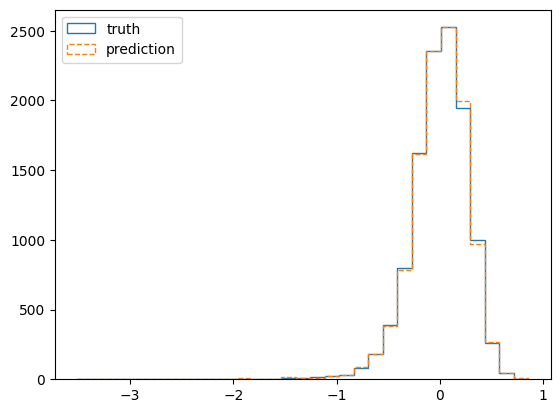

In [38]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()


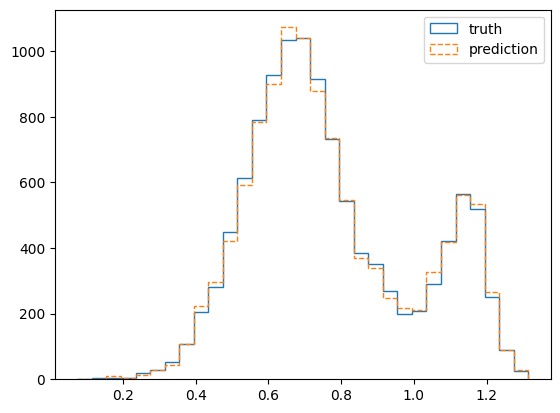

In [39]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step', label='truth')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--', label='prediction');
plt.legend()

In [40]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(3638)

(array([2.46050083, 2.36974484, 2.01463826, 2.08069198, 1.83304305,
        1.76693684, 1.69262641, 1.58533453, 1.23025041, 1.50272198,
        1.58533453, 1.18896684, 1.25502056, 1.06514663, 1.13116984,
        1.05685942, 0.86697982, 0.83392813, 0.94126542, 0.80092421,
        0.76787442]),
 array([ 9.50012016,  9.53342056,  9.56672001,  9.60002041,  9.63332081,
         9.66662025,  9.69992065,  9.73322105,  9.7665205 ,  9.7998209 ,
         9.8331213 ,  9.86642075,  9.89972115,  9.93302155,  9.96632099,
         9.99962139, 10.03292179, 10.06622124, 10.09952164, 10.13282204,
        10.16612148, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x7080a3979950>])

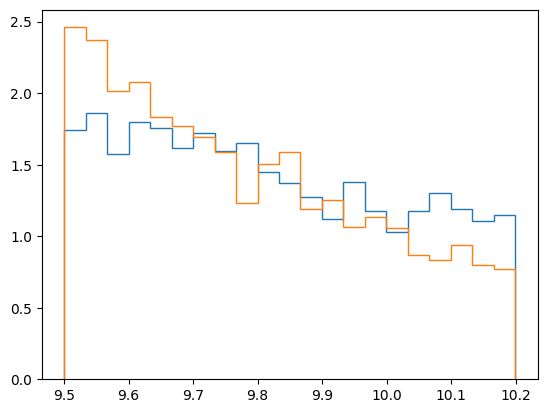

In [41]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step', density=True)
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step', density=True)

In [42]:
# split in red and yellow
smass = np.log10(hydro_data['stellar_mass'][stellar_mask])
mask_red = gi_color[stellar_mask] > 1.0
mask_blue = gi_color[stellar_mask] < 1.0 
smass_red = smass[mask_red]
smass_blue = smass[mask_blue]

pred_color = y_pred[:, 1][pred_stellar_mask]
pred_red_mask = pred_color > 1.0
pred_blue_mask = pred_color < 1.0 


smass_pred_red = pred_mstar[pred_stellar_mask][pred_red_mask]
smass_pred_blue = pred_mstar[pred_stellar_mask][pred_blue_mask]

In [43]:
smass_blue.shape, smass_red.shape, smass_pred_blue.shape, smass_pred_red.shape

((3072,), (983,), (2768,), (870,))

(array([2.31490741, 2.29310547, 1.98886411, 1.98886411, 1.93452356,
        1.74971555, 1.60848026, 1.61934837, 1.28240022, 1.44545861,
        1.6519527 , 1.19549209, 1.26066462, 1.05420666, 1.17375587,
        1.09764764, 0.93465745, 0.83684446, 0.96726178, 0.83682048,
        0.81510824]),
 array([ 9.50012016,  9.53339767,  9.56667614,  9.59995365,  9.63323116,
         9.66650867,  9.69978714,  9.73306465,  9.76634216,  9.79962063,
         9.83289814,  9.86617565,  9.89945316,  9.93273163,  9.96600914,
         9.99928665, 10.03256512, 10.06584263, 10.09912014, 10.13239765,
        10.16567612, 10.19895363]),
 [<matplotlib.patches.Polygon at 0x7080a3808050>])

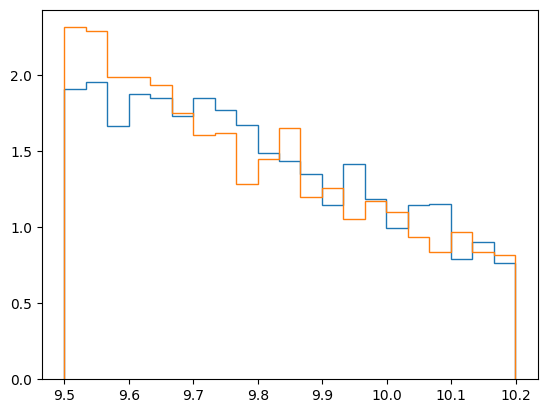

In [44]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( smass_blue, bins=21, histtype='step', density=True)
plt.hist(smass_pred_blue, bins=bins, histtype='step', density=True)

(array([2.87728469, 2.63462212, 2.11463092, 2.32269397, 1.62930579,
        1.76797011, 1.90663443, 1.55997363, 1.0746485 , 1.66397187,
        1.42135004, 1.17864674, 1.21331282, 1.14398066, 1.00531634,
        0.90131809, 0.65865553, 0.83200978, 0.86665201, 0.58932337,
        0.69332161]),
 array([ 9.50071716,  9.53398895,  9.56726074,  9.60053253,  9.63380337,
         9.66707516,  9.70034695,  9.73361874,  9.76689053,  9.80016232,
         9.8334341 ,  9.86670494,  9.89997673,  9.93324852,  9.96652031,
         9.9997921 , 10.03306389, 10.06633568, 10.09960651, 10.1328783 ,
        10.16615009, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x7080a3859f90>])

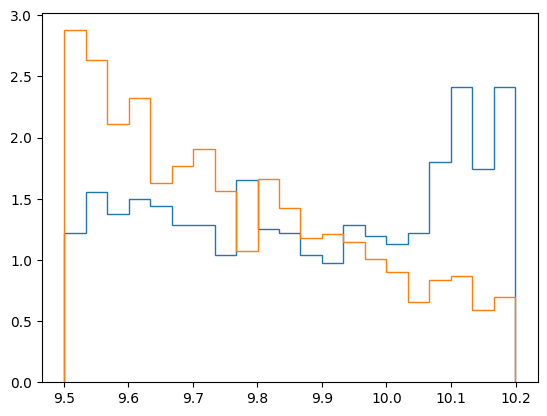

In [45]:
_, bins, _ = plt.hist( smass_red, bins=21, histtype='step', density=True)
plt.hist(smass_pred_red, bins=bins, histtype='step', density=True)

# MultiCAM MAH (no scatter)

In [53]:
x = mah
y = np.stack([mstar_dev, gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 100), (11316, 2))

In [54]:
model = MultiCAM(x.shape[1], 2)
model.fit(x,y)

In [55]:
y_pred = model.predict(x)
y_pred.shape

(11316, 2)

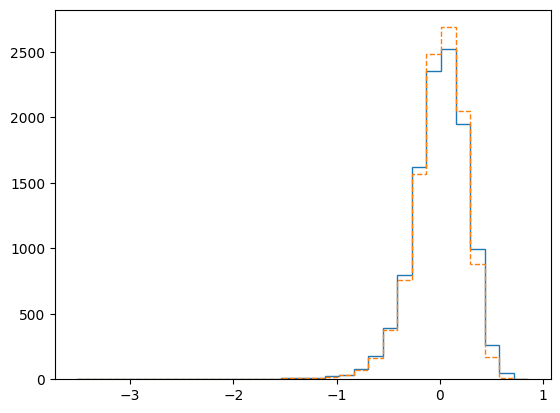

In [56]:
# check marginals 
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');


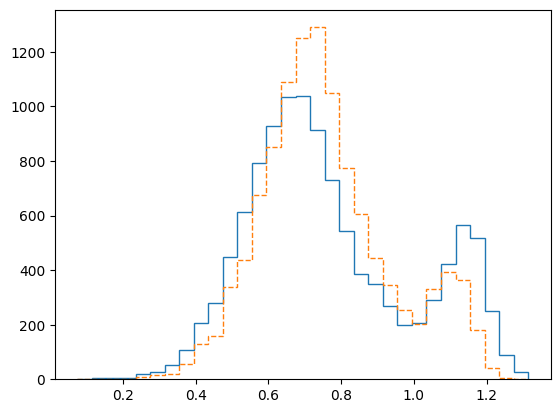

In [57]:
_, bins, _ = plt.hist(y[:, 1], bins=31, histtype='step')
plt.hist(y_pred[:, 1], bins=bins, histtype='step', ls='--');

In [58]:
# prediction spearmanr (these are what we expect I think)
# higher than a_1/2 but color distribution is wonky...
spearmanr(y_pred[:, 0], y[:, 0]), spearmanr(y_pred[:, 1], y[:, 1])

(SignificanceResult(statistic=np.float64(0.6718587731956432), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.7270175527734608), pvalue=np.float64(0.0)))

In [59]:
# obtain haloes within stellar mass bin 
_pred_mstar_dev = y_pred[:, 0]
_mpeak = mpeak[mpeak_mask]
pred_mstar = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak) + _pred_mstar_dev
pred_stellar_mask = (pred_mstar > stellar_mass_bin[0]) & (pred_mstar < stellar_mass_bin[1])
sum(pred_stellar_mask)
# plt.plot(pred_mstar, smass, 'o')

np.int64(3545)

In [60]:
# actual number of stars in bin
smass_true = np.log10(hydro_data['stellar_mass'][mpeak_mask])
sum((smass_true > 9.5) & (smass_true < 10.2))

np.int64(4002)

(array([270., 284., 273., 233., 207., 205., 188., 203., 170., 181., 158.,
        153., 148., 161., 133., 113.,  87., 101.,  98.,  90.,  83.]),
 array([ 9.50012016,  9.53342056,  9.56672001,  9.60002041,  9.63332081,
         9.66662025,  9.69992065,  9.73322105,  9.7665205 ,  9.7998209 ,
         9.8331213 ,  9.86642075,  9.89972115,  9.93302155,  9.96632099,
         9.99962139, 10.03292179, 10.06622124, 10.09952164, 10.13282204,
        10.16612148, 10.19942188]),
 [<matplotlib.patches.Polygon at 0x7080a2e9ac10>])

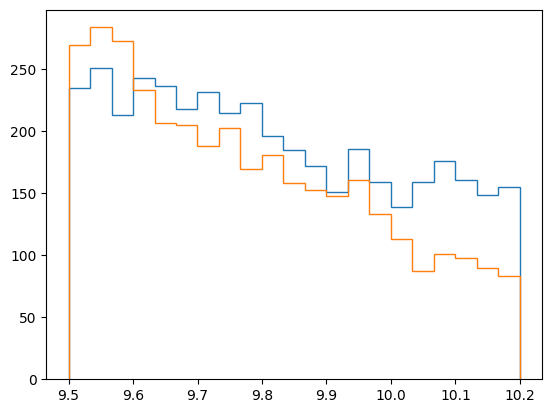

In [61]:
# stellar mass distribution compare between prediction and truth
_, bins, _ = plt.hist( np.log10(hydro_data['stellar_mass'][stellar_mask]), bins=21, histtype='step')
plt.hist(pred_mstar[pred_stellar_mask], bins=bins, histtype='step')